In [ ]:
import gymnasium as gym

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
import scipy as sp
import scipy.stats as st
import scipy.integrate as integrate
from scipy.stats import multivariate_normal
from sklearn import linear_model
#from sklearn.utils.testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning
from matplotlib.colors import LogNorm
import random
from tqdm import tqdm

sns.set_style("whitegrid")
sns.set_palette("colorblind")
palette = sns.color_palette()
figsize = (15,8)
legend_fontsize = 16

## OpenAI Gym

In [ ]:
env = gym.make('FrozenLake-v1', render_mode="ansi")
env.reset();
for _ in range(5):
    print(env.render())
    env.step(env.action_space.sample()) # take a random action
env.close()

## TD-обучение: on-policy (Sarsa)

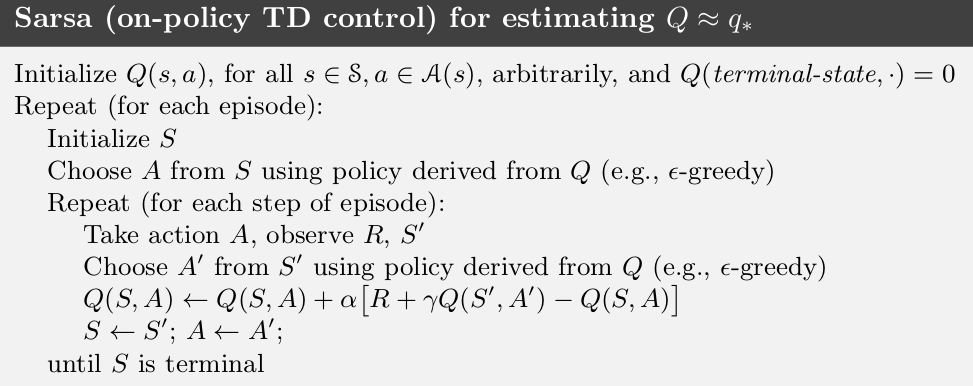![title](SARSA.png)

In [ ]:
nS, nA = env.observation_space.n, env.action_space.n    #type: ignore
nS, nA

In [ ]:
final_states = np.where([ len(env.unwrapped.P[x][0]) == 1 and env.unwrapped.P[x][0][0][3] == True for x in env.unwrapped.P.keys() ])[0] #type: ignore
final_states

In [ ]:
def get_random_Q(env):
    Q = np.random.random(size=(nS, nA))
    Q[final_states, :] = 0.0
    return Q

def compute_policy_by_Q(env, Q):
    return np.argmax(Q, axis=1)

In [ ]:
get_random_Q(env)

In [ ]:
def Sarsa_learning_episode(env, pi, Q, alpha=0.05, epsilon=0.0, gamma=0.9):
    env.reset()
    s, a = env.unwrapped.s, pi[env.unwrapped.s] if np.random.rand() > epsilon else np.random.randint(nA)
    for _ in range(1000):
        observation, reward, terminated, truncated, info = env.step(a)
        s_prime, a_prime = env.unwrapped.s, pi[env.unwrapped.s] if np.random.rand() > epsilon else np.random.randint(nA)
        Q[s][a] = Q[s][a] + alpha * (reward + gamma * Q[s_prime][a_prime] - Q[s][a])
        s, a = s_prime, a_prime
        if terminated:
            break

In [ ]:
env = gym.make('FrozenLake-v1', render_mode="ansi")
env._max_episode_steps = 10000  # type: ignore
total_episodes = 20000
gamma = 0.9

Q_hist_Sarsa = [ ]

Q = get_random_Q(env)
pi = compute_policy_by_Q(env, Q)

for n in tqdm(range(1, total_episodes+1)):
    Sarsa_learning_episode(env, pi, Q, alpha=0.1, epsilon= 1. / (np.log(n)+1), gamma=gamma)
    pi = compute_policy_by_Q(env, Q)
    Q_hist_Sarsa.append(np.copy(Q))

env.close()

In [ ]:
print(env.render())

LEFT = 0

DOWN = 1

RIGHT = 2

UP = 3

In [ ]:
#print("Лучшая стратегия:\n%s" % np.reshape(pi_max, (4, 4)))
print("Текущая стратегия:\n%s" % np.reshape(pi, (4, 4)))

In [ ]:
np.set_printoptions(precision=6, suppress=True)
print("Полученная функция Q:\n%s" % (np.array(Q)))

In [ ]:
def conduct_experiments_pi(env, pi, num_experiments=1000):
    num_steps, total_reward = [], []
    for _ in range(num_experiments):
        env.reset()
        num_steps.append(0)
        total_reward.append(0)
        for _ in range(1000):
            observation, reward, terminated, truncated, info = env.step(pi[env.unwrapped.s])
            total_reward[-1] += reward
            num_steps[-1] += 1
            if terminated:
                break
    env.close()
    return np.mean(total_reward), np.mean(num_steps)

In [ ]:
# Протестируем, как хорошо работают стратегии и как быстро учатся
# Играется total_episodes эпизодов, в каждом эпизоде 10 стратегий
# и после каждого эпизода усредняется результат по 10 стартегиям по 50 доп эпизодам

env = gym.make('FrozenLake-v1', render_mode="ansi")
env._max_episode_steps = 10000  #type: ignore

num_experiments, num_experiments_pi = 10, 50

total_episodes = 1000
gamma = 0.9

results_sarsa = []

Q_arr = [ get_random_Q(env) for _ in range(num_experiments) ]
pi_arr = [ compute_policy_by_Q(env, Q) for Q in Q_arr ]

for n in tqdm(range(1, total_episodes+1)):
    _ = [ Sarsa_learning_episode(env, pi_arr[i], Q_arr[i], alpha=0.1, epsilon= 1. / (np.log(n)+1) , gamma=gamma) for i in range(num_experiments) ]
    pi_arr = [ compute_policy_by_Q(env, Q) for Q in Q_arr ]
    result = [ conduct_experiments_pi(env, pi, num_experiments=num_experiments_pi) for pi in pi_arr ]
    results_sarsa.append([ [x[0], x[1]] for x in result ])

env.close()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax2 = ax.twinx()
ax2.grid(None)

avg_returns = np.mean( np.array([ [x[0] for x in res] for res in results_sarsa]), axis=1)
avg_steps = np.mean( np.array([ [x[1] for x in res] for res in results_sarsa]), axis=1)

line1 = ax.plot(np.arange(1, total_episodes+1), avg_returns, label="Средний результат стратегии в Sarsa", color="C0")
line2 = ax2.plot(np.arange(1, total_episodes+1), avg_steps, label="Среднее число шагов в Sarsa", color="C1")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc=0) #type: ignore
# ax.set_xlim((0.5, 1.0))
# ax.legend(loc="upper right")
ax.set_xlim((1, total_episodes))
ax.set_xlabel("Эпизоды")

## TD-обучение: off-policy (Q-обучение)

![](https://habrastorage.org/webt/wf/6x/fi/wf6xfiyazgu0echvfsw8d9-oly4.png)

In [ ]:
def Q_learning_episode(env, pi, Q, alpha=0.05, epsilon=0.0, gamma=0.9):
    env.reset()
    s, a = env.unwrapped.s, pi[env.unwrapped.s] if np.random.rand() > epsilon else np.random.randint(nA)
    for _ in range(1000):
        observation, reward, terminated, truncated, info = env.step(a)
        s_prime, a_prime = env.unwrapped.s, pi[env.unwrapped.s] if np.random.rand() > epsilon else np.random.randint(nA)
        Q[s][a] = Q[s][a] + alpha * (reward + gamma * np.max( Q[s_prime] ) - Q[s][a])
        s, a = s_prime, a_prime
        if terminated:
            break

In [ ]:
env = gym.make('FrozenLake-v1', render_mode="ansi")
env._max_episode_steps = 10000
total_episodes = 15000
gamma = 0.9


Q_hist_Qlearn = [ ]

Q = get_random_Q(env)
pi = compute_policy_by_Q(env, Q)

for n in tqdm(range(total_episodes)):
    Q_learning_episode(env, pi, Q, alpha=0.1, epsilon= 0.1, gamma=gamma)
    pi = compute_policy_by_Q(env, Q)
    Q_hist_Qlearn.append(np.copy(Q))

env.close()

In [ ]:
print(env.render())

In [ ]:
LEFT = 0
DOWN = 1
RIGHT = 2
UP = 3

In [ ]:
print("Текущая стратегия:\n%s" % np.reshape(pi, (4, 4)))

In [ ]:
np.set_printoptions(precision=6, suppress=True)
print("Полученная функция Q:\n%s" % (np.array(Q)))

In [ ]:
# Протестируем, как хорошо работают стратегии и как быстро учатся
env = gym.make('FrozenLake-v1', render_mode="ansi")
env._max_episode_steps = 10000

num_experiments, num_experiments_pi = 10, 50

total_episodes = 1000
gamma = 0.9

results_Qlearn = []

Q_arr = [ get_random_Q(env) for _ in range(num_experiments) ]
pi_arr = [ compute_policy_by_Q(env, Q) for Q in Q_arr ]

for n in tqdm(range(1, total_episodes+1)):
    _ = [ Q_learning_episode(env, pi_arr[i], Q_arr[i], alpha=0.1, epsilon= 1. / (np.log(n)+1), gamma=gamma) for i in range(num_experiments) ]
    pi_arr = [ compute_policy_by_Q(env, Q) for Q in Q_arr ]
    result = [ conduct_experiments_pi(env, pi, num_experiments=num_experiments_pi) for pi in pi_arr ]
    results_Qlearn.append([ [x[0], x[1]] for x in result ])

env.close()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax2 = ax.twinx()
ax2.grid(None)

avg_returns_Q = np.mean( np.array([ [x[0] for x in res] for res in results_Qlearn]), axis=1)
avg_steps_Q = np.mean( np.array([ [x[1] for x in res] for res in results_Qlearn]), axis=1)

line1 = ax.plot(np.arange(1, total_episodes+1), avg_returns, label="Средний результат стратегии в Sarsa", color="C0", alpha=0.4)
line2 = ax2.plot(np.arange(1, total_episodes+1), avg_steps, label="Среднее число шагов в Sarsa", color="C1", alpha=0.4)
line3 = ax.plot(np.arange(1, total_episodes+1), avg_returns_Q, label="Средний результат стратегии в Q-обучении", color="C2")
line4 = ax2.plot(np.arange(1, total_episodes+1), avg_steps_Q, label="Среднее число шагов в Q-обучении", color="C3")

lines = line1 + line3 + line2 + line4
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")
# ax.set_xlim((0.5, 1.0))
ax.set_xlim((1, total_episodes))
ax.set_xlabel("Эпизоды");